# 🏆 Hackathon — Détection de Fraude Mobile Money

---

**Objectif :** Prédire la probabilité qu'une transaction mobile money soit frauduleuse.

**Métrique d'évaluation :** Average Precision (PR-AUC) — adaptée aux problèmes déséquilibrés.

**Plan du notebook :**
1. Importation des bibliothèques
2. Chargement des données
3. Exploration des données (EDA)
4. Visualisations
5. Feature Engineering
6. Préparation pour la modélisation
7. Modélisation avec Cross-Validation
8. Évaluation des modèles
9. Ensemble des modèles
10. Calibration des probabilités
11. Génération du fichier de soumission

In [1]:
# Installation des bibliothèques nécessaires (à exécuter une seule fois)
import subprocess, sys

packages = ['lightgbm', 'xgboost', 'catboost']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'✅ {pkg} déjà installé')
    except ImportError:
        print(f'📦 Installation de {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'✅ {pkg} installé avec succès')

print('\n✅ Toutes les bibliothèques sont prêtes !')

✅ lightgbm déjà installé
✅ xgboost déjà installé
✅ catboost déjà installé

✅ Toutes les bibliothèques sont prêtes !


---
## Étape 1 — Importation des Bibliothèques

On commence par importer toutes les bibliothèques nécessaires :
- **pandas / numpy** : manipulation des données
- **matplotlib / seaborn** : visualisation
- **sklearn** : métriques, validation croisée, calibration
- **lightgbm / xgboost / catboost** : modèles gradient boosting (les meilleurs pour ce type de données tabulaires)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression

# Modèles
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


---
## Étape 2 — Chargement des Données

On charge les 3 fichiers fournis par le hackathon :
- `train.csv` : données d'entraînement avec la colonne cible `fraud_flag`
- `test.csv` : données de test sans la cible (à prédire)
- `sample_submission.csv` : format attendu pour la soumission

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

print(f'Train  : {train.shape[0]:,} lignes × {train.shape[1]} colonnes')
print(f'Test   : {test.shape[0]:,} lignes × {test.shape[1]} colonnes')
print(f'Submit : {sub.shape[0]:,} lignes × {sub.shape[1]} colonnes')

Train  : 1,290,081 lignes × 11 colonnes
Test   : 430,100 lignes × 10 colonnes
Submit : 430,100 lignes × 2 colonnes


---
## Étape 3 — Exploration des Données (EDA)

L'**EDA (Exploratory Data Analysis)** est une étape cruciale. Elle permet de :
- Comprendre la structure et le sens des données
- Détecter les valeurs manquantes ou aberrantes
- Identifier le déséquilibre de classes
- Trouver des patterns liés à la fraude

In [4]:
# Aperçu des premières lignes
print('=== Aperçu du dataset d\'entraînement ===')
train.head()

=== Aperçu du dataset d'entraînement ===


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.7500,acc_o_307358626ad66fed,87.0000,-549.7500,acc_d_7fac3b16af7d127b,630.8800,1267.6200,0
1,dtf_0000002_61992e82,0,op_05,636.1200,acc_o_aeb690c57bf5d1de,76.9300,76.9300,acc_d_1d6120e8b117aa14,731.7000,731.7000,0
2,dtf_0000003_9a123b6d,0,op_05,681.0000,acc_o_655c41913944d2b7,15943.7400,15262.7500,acc_d_ec2c21517a0ccb1a,758.8300,1439.8400,0
3,dtf_0000004_240f3dae,0,op_03,28175.4000,acc_o_ba23a2b955a79a8b,-443.8800,-28619.2800,acc_d_a3dd8504815ec133,770924.8400,799100.2400,0
4,dtf_0000005_f18939e7,0,op_03,86429.1500,acc_o_d05a23079bd066c1,-670.8500,-87100.0100,acc_d_0d4880267e62d5c4,91.1300,86520.2900,0


In [5]:
# Types de données et informations générales
print('=== Informations générales ===')
train.info()

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 11 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1290081 non-null  object 
 1   period                      1290081 non-null  int64  
 2   operation                   1290081 non-null  object 
 3   amount                      1290081 non-null  float64
 4   origin_account              1290081 non-null  object 
 5   origin_balance_before       1290081 non-null  float64
 6   origin_balance_after        1290081 non-null  float64
 7   destination_account         1290081 non-null  object 
 8   destination_balance_before  1290081 non-null  float64
 9   destination_balance_after   1290081 non-null  float64
 10  fraud_flag                  1290081 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 108.3+ MB


In [6]:
# Statistiques descriptives des variables numériques
print('=== Statistiques descriptives ===')
train.describe().round(2)

=== Statistiques descriptives ===


,period,amount,origin_balance_before,origin_balance_after,destination_balance_before,destination_balance_after,fraud_flag
count,1290081.0000,1290081.0000,1290081.0000,1290081.0000,1290081.0000,1290081.0000,1290081.0000
mean,44.6300,64160.3800,2875629.4100,2889497.4100,108005.7200,124235.5900,0.1000
std,29.4600,105555.4300,1595036.1400,1579518.4000,329081.2000,372757.7400,0.3000
min,0.0000,0.3700,-235838.1500,-235838.1500,-233917.6400,-160051.4900,0.0000
25%,18.0000,717.3500,1766371.9900,1803915.9000,8662.1100,23270.0100,0.0000
50%,40.0000,20506.1600,3127788.3800,3134522.9400,55218.0900,68299.7600,0.0000
75%,68.0000,87523.9100,4031736.3900,4030584.9100,127411.9400,135647.7600,0.0000
max,105.0000,2526957.6700,14439035.4800,14439035.4800,14015520.3500,14228571.0600,1.0000


In [7]:
# Vérification des valeurs manquantes
missing = pd.DataFrame({
    'Train — Manquants'  : train.isnull().sum(),
    'Train — %'          : (train.isnull().mean() * 100).round(2),
    'Test — Manquants'   : test.isnull().sum(),
    'Test — %'           : (test.isnull().mean() * 100).round(2),
})

print('=== Valeurs manquantes ===')
if missing['Train — Manquants'].sum() == 0:
    print('✅ Aucune valeur manquante dans train')
else:
    display(missing[missing['Train — Manquants'] > 0])

if missing['Test — Manquants'].sum() == 0:
    print('✅ Aucune valeur manquante dans test')
else:
    display(missing[missing['Test — Manquants'] > 0])

=== Valeurs manquantes ===
✅ Aucune valeur manquante dans train
✅ Aucune valeur manquante dans test


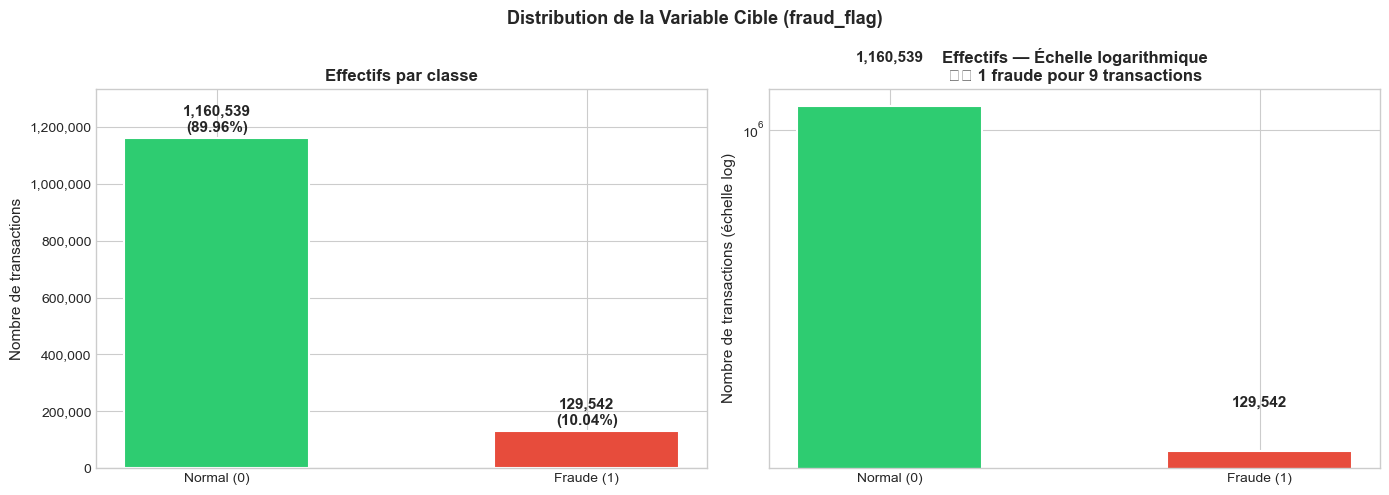

Transactions normales  (0) : 1,160,539  (89.96%)
Transactions frauduleuses (1): 129,542  (10.04%)


In [28]:
# Distribution de la variable cible — histogramme
vc = train['fraud_flag'].value_counts()
fraud_rate = train['fraud_flag'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution de la Variable Cible (fraud_flag)', fontsize=13, fontweight='bold')

# --- Histogramme (barplot) des effectifs ---
ax = axes[0]
bars = ax.bar(
    ['Normal (0)', 'Fraude (1)'],
    [vc[0], vc.get(1, 0)],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars, [vc[0], vc.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc)*0.01,
            f'{val:,}\n({val/len(train)*100:.2f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel("Nombre de transactions", fontsize=11)
ax.set_title("Effectifs par classe", fontweight='bold')
ax.set_ylim(0, max(vc) * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Histogramme en échelle log (pour mieux voir la fraude) ---
ax = axes[1]
bars2 = ax.bar(
    ['Normal (0)', 'Fraude (1)'],
    [vc[0], vc.get(1, 0)],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars2, [vc[0], vc.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel("Nombre de transactions (échelle log)", fontsize=11)
ax.set_title(f"Effectifs — Échelle logarithmique\n⚠️ 1 fraude pour {int(1/fraud_rate):,} transactions", fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Transactions normales  (0) : {vc[0]:,}  ({100-fraud_rate*100:.2f}%)')
print(f'Transactions frauduleuses (1): {vc.get(1,0):,}  ({fraud_rate*100:.2f}%)')


In [9]:
# Cardinalité des variables catégorielles
cat_cols = ['operation', 'origin_account', 'destination_account']
print('=== Cardinalité des variables catégorielles ===')
for col in cat_cols:
    n_train = train[col].nunique()
    n_test  = test[col].nunique()
    print(f'  {col:<30} Train: {n_train:>8,} | Test: {n_test:>8,}')

print(f'\n  Types d\'opérations dans train : {sorted(train["operation"].unique())}')

print(f'\n  Période temporelle:')
print(f'    Train — min: {train["period"].min()} | max: {train["period"].max()}')
print(f'    Test  — min: {test["period"].min()} | max: {test["period"].max()}')

=== Cardinalité des variables catégorielles ===
  operation                      Train:        5 | Test:        5
  origin_account                 Train:   13,431 | Test:   10,253
  destination_account            Train:   15,818 | Test:   13,516

  Types d'opérations dans train : ['op_01', 'op_02', 'op_03', 'op_04', 'op_05']

  Période temporelle:
    Train — min: 0 | max: 105
    Test  — min: 106 | max: 143


In [10]:
# Taux de fraude par type d'opération
fraud_by_op = train.groupby('operation')['fraud_flag'].agg(
    taux_fraude='mean',
    nb_transactions='count',
    nb_fraudes='sum'
).round(4)
fraud_by_op['taux_fraude_%'] = (fraud_by_op['taux_fraude'] * 100).round(2)
fraud_by_op.sort_values('taux_fraude', ascending=False)

,taux_fraude,nb_transactions,nb_fraudes,taux_fraude_%
operation,,,,
op_03,0.3119,415323,129542,31.1900
op_01,0.0000,4087,0,0.0000
op_02,0.0000,71876,0,0.0000
op_04,0.0000,305443,0,0.0000
op_05,0.0000,493352,0,0.0000


---
## Étape 4 — Visualisations

Les visualisations permettent de mieux comprendre les données que les chiffres seuls.
On va tracer :
- La distribution Fraude / Normal
- La distribution du montant par classe
- Le taux de fraude par type d'opération
- L'évolution temporelle de la fraude
- Les corrélations entre variables

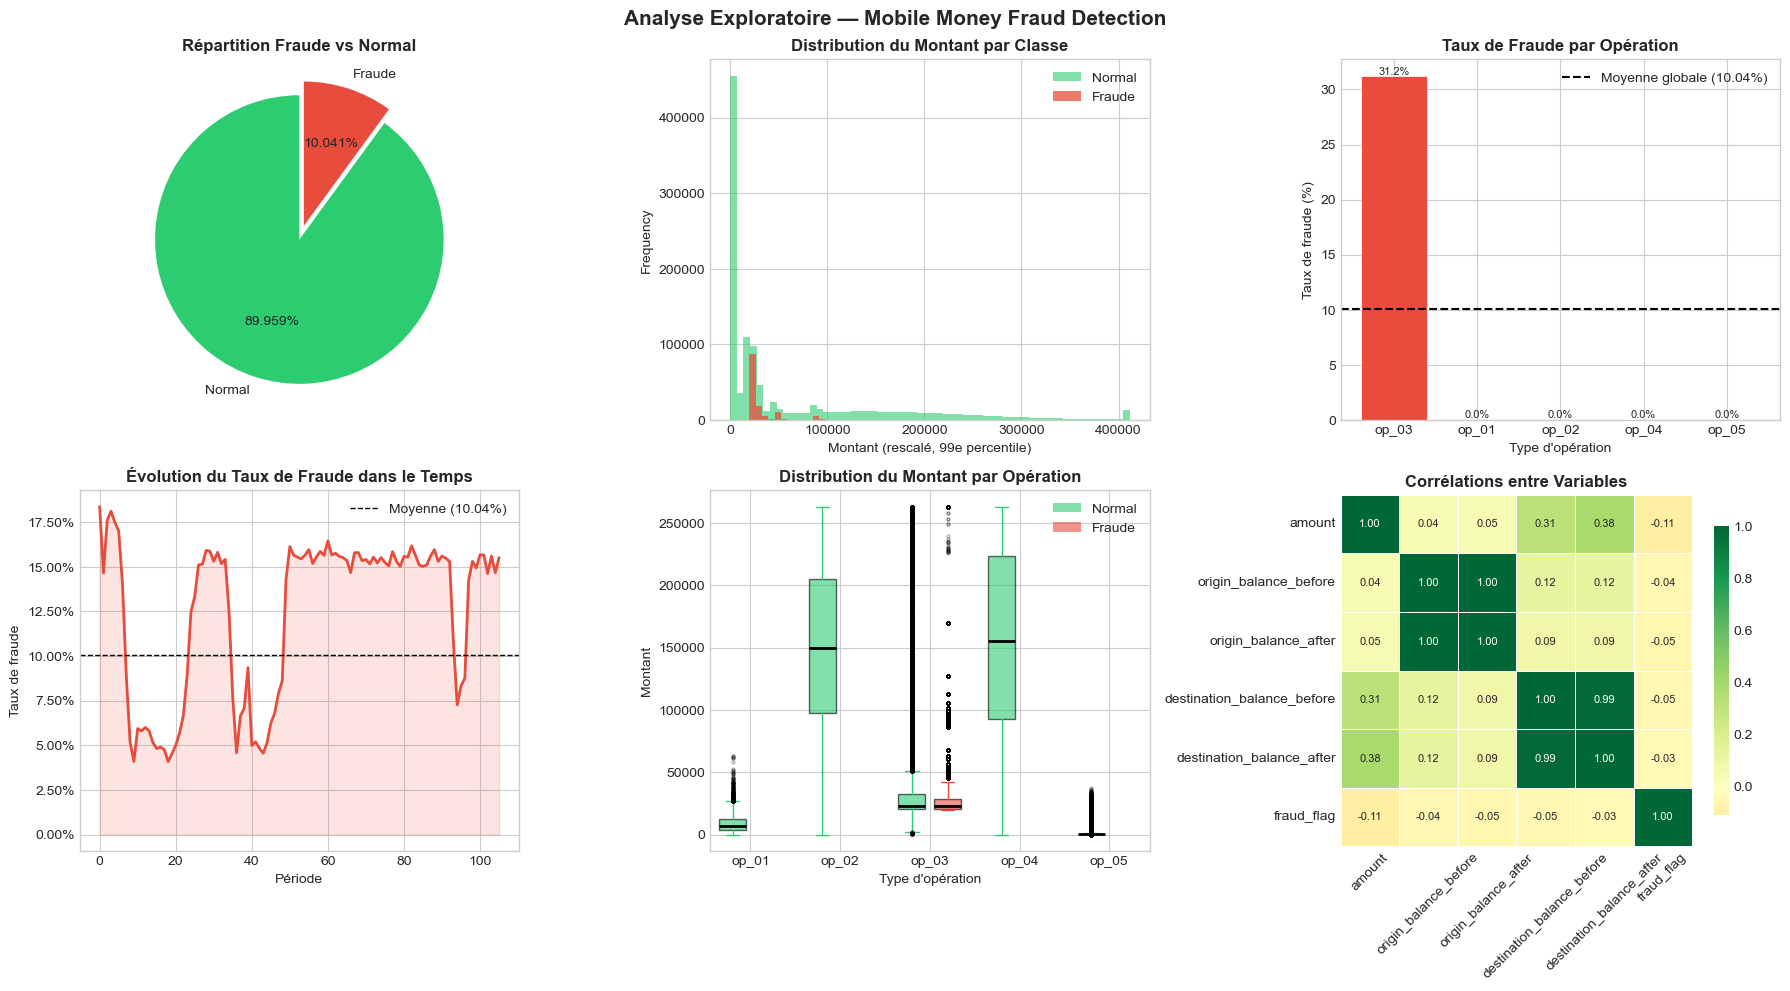

✅ Graphiques EDA sauvegardés → eda_visualizations.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire — Mobile Money Fraud Detection', fontsize=15, fontweight='bold')

# 1. Pie chart : répartition fraude/normal
ax = axes[0, 0]
wedges, texts, autotexts = ax.pie(
    [vc[0], vc.get(1,0)],
    labels=['Normal', 'Fraude'],
    autopct='%1.3f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.1)
)
ax.set_title('Répartition Fraude vs Normal', fontweight='bold')

# 2. Distribution du montant par classe
ax = axes[0, 1]
cap = train['amount'].quantile(0.99)
train.loc[train['fraud_flag']==0, 'amount'].clip(upper=cap).plot(
    kind='hist', bins=60, alpha=0.6, color='#2ecc71', label='Normal', ax=ax)
train.loc[train['fraud_flag']==1, 'amount'].clip(upper=cap).plot(
    kind='hist', bins=60, alpha=0.75, color='#e74c3c', label='Fraude', ax=ax)
ax.set_title('Distribution du Montant par Classe', fontweight='bold')
ax.set_xlabel('Montant (rescalé, 99e percentile)'); ax.legend()

# 3. Taux de fraude par type d'opération
ax = axes[0, 2]
fbo = train.groupby('operation')['fraud_flag'].mean().sort_values(ascending=False)
colors_op = ['#e74c3c' if v > fraud_rate else '#3498db' for v in fbo.values]
bars = ax.bar(fbo.index, fbo.values * 100, color=colors_op, edgecolor='white', linewidth=0.5)
ax.axhline(fraud_rate * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Moyenne globale ({fraud_rate*100:.2f}%)')
for bar, val in zip(bars, fbo.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_title('Taux de Fraude par Opération', fontweight='bold')
ax.set_xlabel("Type d'opération"); ax.set_ylabel('Taux de fraude (%)'); ax.legend()

# 4. Évolution temporelle du taux de fraude
ax = axes[1, 0]
fraud_by_period = train.groupby('period')['fraud_flag'].mean()
ax.plot(fraud_by_period.index, fraud_by_period.values, color='#e74c3c', linewidth=2)
ax.fill_between(fraud_by_period.index, fraud_by_period.values, alpha=0.15, color='#e74c3c')
ax.axhline(fraud_rate, color='black', linestyle='--', linewidth=1, label=f'Moyenne ({fraud_rate*100:.2f}%)')
ax.set_title('Évolution du Taux de Fraude dans le Temps', fontweight='bold')
ax.set_xlabel('Période'); ax.set_ylabel('Taux de fraude'); ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))

# 5. Boxplot montant par opération et classe
ax = axes[1, 1]
cap2 = train['amount'].quantile(0.95)
train_clipped = train.copy()
train_clipped['amount_clipped'] = train_clipped['amount'].clip(upper=cap2)
order_ops = sorted(train['operation'].unique())
for i, (label, color) in enumerate([(0, '#2ecc71'), (1, '#e74c3c')]):
    subset = train_clipped[train_clipped['fraud_flag'] == label]
    positions = [j*2 + i*0.8 for j in range(len(order_ops))]
    bplot = ax.boxplot(
        [subset[subset['operation'] == op]['amount_clipped'].values for op in order_ops],
        positions=positions, widths=0.6, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(marker='o', color=color, markersize=2, alpha=0.3)
    )
ax.set_xticks([j*2 + 0.4 for j in range(len(order_ops))])
ax.set_xticklabels(order_ops)
ax.set_title('Distribution du Montant par Opération', fontweight='bold')
ax.set_xlabel("Type d'opération"); ax.set_ylabel('Montant')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2ecc71', alpha=0.6, label='Normal'),
                   Patch(facecolor='#e74c3c', alpha=0.6, label='Fraude')])

# 6. Heatmap des corrélations
ax = axes[1, 2]
num_cols = ['amount','origin_balance_before','origin_balance_after',
            'destination_balance_before','destination_balance_after','fraud_flag']
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Corrélations entre Variables', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphiques EDA sauvegardés → eda_visualizations.png')

---
## Étape 5 — Feature Engineering

C'est l'étape la plus importante pour la performance du modèle. On crée de nouvelles variables à partir des données brutes.

**Stratégie :**
1. **Features d'anomalie de balance** : vérifier si les soldes avant/après correspondent au montant transféré
2. **Features de ratio** : montant par rapport au solde disponible
3. **Features comportementales** : agrégations par compte (fréquence, montants, diversité)
4. **Features de vélocité** : activité par période
5. **Features statistiques** : z-score du montant dans sa catégorie d'opération

> 💡 On combine **train + test** avant de calculer les agrégations, pour que les statistiques soient cohérentes.

In [12]:
# Combiner train et test pour les agrégations globales
train['is_train'] = 1
test['is_train']  = 0
test['fraud_flag'] = -1  # placeholder

full = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Dataset combiné : {full.shape[0]:,} lignes × {full.shape[1]} colonnes')

Dataset combiné : 1,720,181 lignes × 12 colonnes


In [13]:
# ── 5.1 Features d'anomalie de balance ─────────────────────────────
# Théorie : balance_after = balance_before - amount (émetteur)
#           balance_after = balance_before + amount (destinataire)
# Un écart signale une anomalie potentielle

full['origin_expected_balance_after'] = full['origin_balance_before'] - full['amount']
full['dest_expected_balance_after']   = full['destination_balance_before'] + full['amount']

full['origin_balance_error'] = (full['origin_balance_after'] - full['origin_expected_balance_after']).abs()
full['dest_balance_error']   = (full['destination_balance_after'] - full['dest_expected_balance_after']).abs()

full['has_balance_anomaly'] = (
    (full['origin_balance_error'] > 0.01) | (full['dest_balance_error'] > 0.01)
).astype(int)

# Vérification sur le train
anomaly_fraud_rate = full[full['is_train']==1].groupby('has_balance_anomaly')['fraud_flag'].mean()
print('Taux de fraude selon anomalie de balance :')
print(anomaly_fraud_rate.to_string())

Taux de fraude selon anomalie de balance :
has_balance_anomaly
0   0.1443
1   0.0712


In [14]:
# ── 5.2 Features de ratio montant / solde ──────────────────────────
full['amount_to_origin_balance']   = full['amount'] / (full['origin_balance_before'].abs() + 1e-6)
full['amount_to_dest_balance']     = full['amount'] / (full['destination_balance_before'].abs() + 1e-6)
full['origin_balance_change_pct']  = full['origin_balance_error'] / (full['origin_balance_before'].abs() + 1e-6)

# Indicateurs binaires
full['origin_balance_negative_before'] = (full['origin_balance_before'] < 0).astype(int)
full['origin_balance_negative_after']  = (full['origin_balance_after'] < 0).astype(int)
full['dest_balance_zero_before']       = (full['destination_balance_before'] == 0).astype(int)
full['dest_balance_zero_after']        = (full['destination_balance_after'] == 0).astype(int)
full['amount_is_round']               = (full['amount'] % 100 < 1e-6).astype(int)

print('✅ Features de ratio créées')

✅ Features de ratio créées


In [15]:
# ── 5.3 Agrégations par compte émetteur ────────────────────────────
print('Calcul des agrégations par compte émetteur...')

origin_agg = full.groupby('origin_account').agg(
    origin_tx_count          = ('id', 'count'),
    origin_total_amount_sent = ('amount', 'sum'),
    origin_mean_amount       = ('amount', 'mean'),
    origin_std_amount        = ('amount', 'std'),
    origin_max_amount        = ('amount', 'max'),
    origin_min_amount        = ('amount', 'min'),
    origin_unique_dest       = ('destination_account', 'nunique'),
    origin_unique_periods    = ('period', 'nunique'),
    origin_unique_ops        = ('operation', 'nunique'),
).reset_index()
origin_agg['origin_std_amount'] = origin_agg['origin_std_amount'].fillna(0)
origin_agg['origin_amount_cv']  = origin_agg['origin_std_amount'] / (origin_agg['origin_mean_amount'] + 1e-6)

full = full.merge(origin_agg, on='origin_account', how='left')
print(f'  → {len(origin_agg):,} comptes émetteurs uniques')

Calcul des agrégations par compte émetteur...
  → 13,462 comptes émetteurs uniques


In [16]:
# ── 5.4 Agrégations par compte destinataire ─────────────────────────
print('Calcul des agrégations par compte destinataire...')

dest_agg = full.groupby('destination_account').agg(
    dest_tx_count          = ('id', 'count'),
    dest_total_amount_recv = ('amount', 'sum'),
    dest_mean_amount       = ('amount', 'mean'),
    dest_std_amount        = ('amount', 'std'),
    dest_max_amount        = ('amount', 'max'),
    dest_unique_senders    = ('origin_account', 'nunique'),
    dest_unique_periods    = ('period', 'nunique'),
).reset_index()
dest_agg['dest_std_amount'] = dest_agg['dest_std_amount'].fillna(0)
dest_agg['dest_amount_cv']  = dest_agg['dest_std_amount'] / (dest_agg['dest_mean_amount'] + 1e-6)

full = full.merge(dest_agg, on='destination_account', how='left')
print(f'  → {len(dest_agg):,} comptes destinataires uniques')

Calcul des agrégations par compte destinataire...
  → 16,731 comptes destinataires uniques


In [17]:
# ── 5.5 Features de vélocité par période ────────────────────────────
print('Calcul des features de vélocité...')

period_origin = full.groupby(['period', 'origin_account']).agg(
    origin_tx_count_period = ('id', 'count'),
    origin_amount_period   = ('amount', 'sum'),
).reset_index()
full = full.merge(period_origin, on=['period', 'origin_account'], how='left')

# Paire émetteur-destinataire : nombre de fois qu'ils ont transigé ensemble
pair_count = full.groupby(['origin_account', 'destination_account']).size().reset_index(name='pair_tx_count')
full = full.merge(pair_count, on=['origin_account', 'destination_account'], how='left')

# Ratio vélocité : transactions de ce compte dans cette période vs total
full['origin_velocity_ratio'] = full['origin_tx_count_period'] / (full['origin_tx_count'] + 1e-6)

print('✅ Features de vélocité créées')

Calcul des features de vélocité...
✅ Features de vélocité créées


In [18]:
# ── 5.6 Features statistiques par opération ─────────────────────────
op_stats = full.groupby('operation')['amount'].agg(['mean', 'std', 'median']).reset_index()
op_stats.columns = ['operation', 'op_amount_mean', 'op_amount_std', 'op_amount_median']
full = full.merge(op_stats, on='operation', how='left')

# Z-score : à quel point ce montant est-il inhabituel pour ce type d'opération ?
full['amount_zscore_in_op'] = (
    (full['amount'] - full['op_amount_mean']) / (full['op_amount_std'] + 1e-6)
)
full['amount_vs_op_median'] = full['amount'] / (full['op_amount_median'] + 1e-6)

# Z-score du montant par rapport au comportement habituel du compte
full['amount_zscore_origin'] = (
    (full['amount'] - full['origin_mean_amount']) / (full['origin_std_amount'] + 1e-6)
)

# Période en bins (découpée en 10 tranches)
full['period_bin'] = pd.cut(full['period'], bins=10, labels=False)

# Encodage de la variable opération
le = LabelEncoder()
full['operation_encoded'] = le.fit_transform(full['operation'])

print(f'✅ Toutes les features créées → {full.shape[1]} colonnes au total')

✅ Toutes les features créées → 55 colonnes au total


---
## Étape 6 — Préparation pour la Modélisation

On sépare les features (X) de la cible (y), et on re-sépare train/test.

In [19]:
# Colonnes à exclure du modèle
EXCLUDE_COLS = [
    'id', 'origin_account', 'destination_account', 'operation',
    'fraud_flag', 'is_train',
    'origin_expected_balance_after', 'dest_expected_balance_after'
]

FEATURES = [col for col in full.columns if col not in EXCLUDE_COLS]

print(f'Nombre de features : {len(FEATURES)}')
print('\nListe complète des features :')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2}. {f}')

Nombre de features : 47

Liste complète des features :
   1. period
   2. amount
   3. origin_balance_before
   4. origin_balance_after
   5. destination_balance_before
   6. destination_balance_after
   7. origin_balance_error
   8. dest_balance_error
   9. has_balance_anomaly
  10. amount_to_origin_balance
  11. amount_to_dest_balance
  12. origin_balance_change_pct
  13. origin_balance_negative_before
  14. origin_balance_negative_after
  15. dest_balance_zero_before
  16. dest_balance_zero_after
  17. amount_is_round
  18. origin_tx_count
  19. origin_total_amount_sent
  20. origin_mean_amount
  21. origin_std_amount
  22. origin_max_amount
  23. origin_min_amount
  24. origin_unique_dest
  25. origin_unique_periods
  26. origin_unique_ops
  27. origin_amount_cv
  28. dest_tx_count
  29. dest_total_amount_recv
  30. dest_mean_amount
  31. dest_std_amount
  32. dest_max_amount
  33. dest_unique_senders
  34. dest_unique_periods
  35. dest_amount_cv
  36. origin_tx_count_period
  37.

In [20]:
# Séparation train / test
df_train = full[full['is_train'] == 1].copy()
df_test  = full[full['is_train'] == 0].copy()

X_train = df_train[FEATURES]
y_train = df_train['fraud_flag'].astype(int)
X_test  = df_test[FEATURES]

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nRépartition cible :')
print(f'  Normales  (0) : {(y_train==0).sum():,}')
print(f'  Fraudes   (1) : {(y_train==1).sum():,}')
print(f'  Taux fraude   : {y_train.mean():.4%}')

# Ratio de déséquilibre pour scale_pos_weight
SCALE_POS_WEIGHT = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'  scale_pos_weight : {SCALE_POS_WEIGHT}')

X_train : (1290081, 47)
X_test  : (430100, 47)

Répartition cible :
  Normales  (0) : 1,160,539
  Fraudes   (1) : 129,542
  Taux fraude   : 10.0414%
  scale_pos_weight : 8


---
## Étape 7 — Modélisation avec Cross-Validation

On utilise une **validation croisée stratifiée (StratifiedKFold)** pour :
- Avoir une estimation fiable de la performance réelle
- Éviter le surapprentissage (overfitting)
- S'assurer que chaque fold a le même ratio fraude/normal

Les **prédictions OOF (Out-Of-Fold)** permettent d'évaluer le modèle sans biais.

**Modèles utilisés :**
- **LightGBM** : rapide, très efficace sur données tabulaires déséquilibrées
- **XGBoost** : robuste, bonne généralisation
- **CatBoost** : excellent avec les catégorielles, bien calibré

In [21]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Conteneurs pour les prédictions
oof_lgb  = np.zeros(len(X_train))
oof_xgb  = np.zeros(len(X_train))
oof_cat  = np.zeros(len(X_train))

pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

scores_lgb, scores_xgb, scores_cat = [], [], []

# Paramètres LightGBM
lgb_params = {
    'objective'        : 'binary',
    'metric'           : 'average_precision',
    'learning_rate'    : 0.05,
    'num_leaves'       : 127,
    'max_depth'        : -1,
    'min_child_samples': 30,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 0.1,
    'scale_pos_weight' : SCALE_POS_WEIGHT,
    'verbose'          : -1,
    'random_state'     : 42,
}

# Paramètres XGBoost
xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'aucpr',
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'min_child_weight' : 10,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'scale_pos_weight' : SCALE_POS_WEIGHT,
    'verbosity'        : 0,
    'random_state'     : 42,
}

print('✅ Configuration de la cross-validation prête')
print(f'  - Nombre de folds : {N_FOLDS}')
print(f'  - Stratification  : oui (même ratio fraude/normal dans chaque fold)')

✅ Configuration de la cross-validation prête
  - Nombre de folds : 5
  - Stratification  : oui (même ratio fraude/normal dans chaque fold)


In [22]:
# ── Boucle de Cross-Validation ──────────────────────────────────────
for fold, (idx_tr, idx_val) in enumerate(skf.split(X_train, y_train), 1):
    print(f'\n{'─'*55}')
    print(f'  FOLD {fold}/{N_FOLDS}')
    print(f'{'─'*55}')

    Xtr,  Xval  = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    ytr,  yval  = y_train.iloc[idx_tr], y_train.iloc[idx_val]

    # ── LightGBM ──
    dtrain_lgb = lgb.Dataset(Xtr, label=ytr)
    dval_lgb   = lgb.Dataset(Xval, label=yval, reference=dtrain_lgb)
    model_lgb  = lgb.train(
        lgb_params, dtrain_lgb,
        num_boost_round=3000,
        valid_sets=[dval_lgb],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(1000)
        ]
    )
    oof_lgb[idx_val] = model_lgb.predict(Xval)
    pred_lgb         += model_lgb.predict(X_test) / N_FOLDS
    sc_lgb = average_precision_score(yval, oof_lgb[idx_val])
    scores_lgb.append(sc_lgb)
    print(f'  LightGBM  → PR-AUC : {sc_lgb:.5f}  (best iter: {model_lgb.best_iteration})')

    # ── XGBoost ──
    dtrain_xgb = xgb.DMatrix(Xtr, label=ytr)
    dval_xgb   = xgb.DMatrix(Xval, label=yval)
    model_xgb  = xgb.train(
        xgb_params, dtrain_xgb,
        num_boost_round=3000,
        evals=[(dval_xgb, 'val')],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    oof_xgb[idx_val] = model_xgb.predict(dval_xgb)
    pred_xgb         += model_xgb.predict(xgb.DMatrix(X_test)) / N_FOLDS
    sc_xgb = average_precision_score(yval, oof_xgb[idx_val])
    scores_xgb.append(sc_xgb)
    print(f'  XGBoost   → PR-AUC : {sc_xgb:.5f}  (best iter: {model_xgb.best_iteration})')

    # ── CatBoost ──
    model_cat = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='AUC',
        scale_pos_weight=SCALE_POS_WEIGHT,
        early_stopping_rounds=100,
        random_seed=42,
        verbose=False,
    )
    model_cat.fit(Xtr, ytr, eval_set=(Xval, yval), use_best_model=True)
    oof_cat[idx_val] = model_cat.predict_proba(Xval)[:, 1]
    pred_cat         += model_cat.predict_proba(X_test)[:, 1] / N_FOLDS
    sc_cat = average_precision_score(yval, oof_cat[idx_val])
    scores_cat.append(sc_cat)
    print(f'  CatBoost  → PR-AUC : {sc_cat:.5f}')

print(f'\n{"="*55}')
print('  CROSS-VALIDATION TERMINÉE')
print(f'{"="*55}')


───────────────────────────────────────────────────────
  FOLD 1/5
───────────────────────────────────────────────────────
  LightGBM  → PR-AUC : 0.44809  (best iter: 47)
  XGBoost   → PR-AUC : 0.44622  (best iter: 1)
  CatBoost  → PR-AUC : 0.45087

───────────────────────────────────────────────────────
  FOLD 2/5
───────────────────────────────────────────────────────
  LightGBM  → PR-AUC : 0.44802  (best iter: 10)
  XGBoost   → PR-AUC : 0.44820  (best iter: 80)
  CatBoost  → PR-AUC : 0.44873

───────────────────────────────────────────────────────
  FOLD 3/5
───────────────────────────────────────────────────────
  LightGBM  → PR-AUC : 0.45273  (best iter: 42)
  XGBoost   → PR-AUC : 0.45075  (best iter: 43)
  CatBoost  → PR-AUC : 0.45079

───────────────────────────────────────────────────────
  FOLD 4/5
───────────────────────────────────────────────────────
  LightGBM  → PR-AUC : 0.45219  (best iter: 10)
  XGBoost   → PR-AUC : 0.45151  (best iter: 66)
  CatBoost  → PR-AUC : 0.445

---
## Étape 8 — Évaluation des Modèles

On compare les scores PR-AUC de chaque modèle et on visualise les résultats.

In [23]:
print('╔══════════════════════════════════════════════════════════╗')
print('║          RÉSULTATS PR-AUC — CROSS-VALIDATION             ║')
print('╠══════════════════╦═══════════╦═══════════╦═══════════════╣')
print('║     Modèle       ║  Moyenne  ║    Std    ║    Min — Max  ║')
print('╠══════════════════╬═══════════╬═══════════╬═══════════════╣')
for name, scores in [('LightGBM', scores_lgb), ('XGBoost', scores_xgb), ('CatBoost', scores_cat)]:
    m, s = np.mean(scores), np.std(scores)
    print(f'║ {name:<16} ║ {m:.5f}   ║ {s:.5f}   ║ {min(scores):.4f} — {max(scores):.4f} ║')
print('╚══════════════════╩═══════════╩═══════════╩═══════════════╝')

╔══════════════════════════════════════════════════════════╗
║          RÉSULTATS PR-AUC — CROSS-VALIDATION             ║
╠══════════════════╦═══════════╦═══════════╦═══════════════╣
║     Modèle       ║  Moyenne  ║    Std    ║    Min — Max  ║
╠══════════════════╬═══════════╬═══════════╬═══════════════╣
║ LightGBM         ║ 0.45024   ║ 0.00198   ║ 0.4480 — 0.4527 ║
║ XGBoost          ║ 0.44855   ║ 0.00225   ║ 0.4461 — 0.4515 ║
║ CatBoost         ║ 0.44798   ║ 0.00278   ║ 0.4440 — 0.4509 ║
╚══════════════════╩═══════════╩═══════════╩═══════════════╝


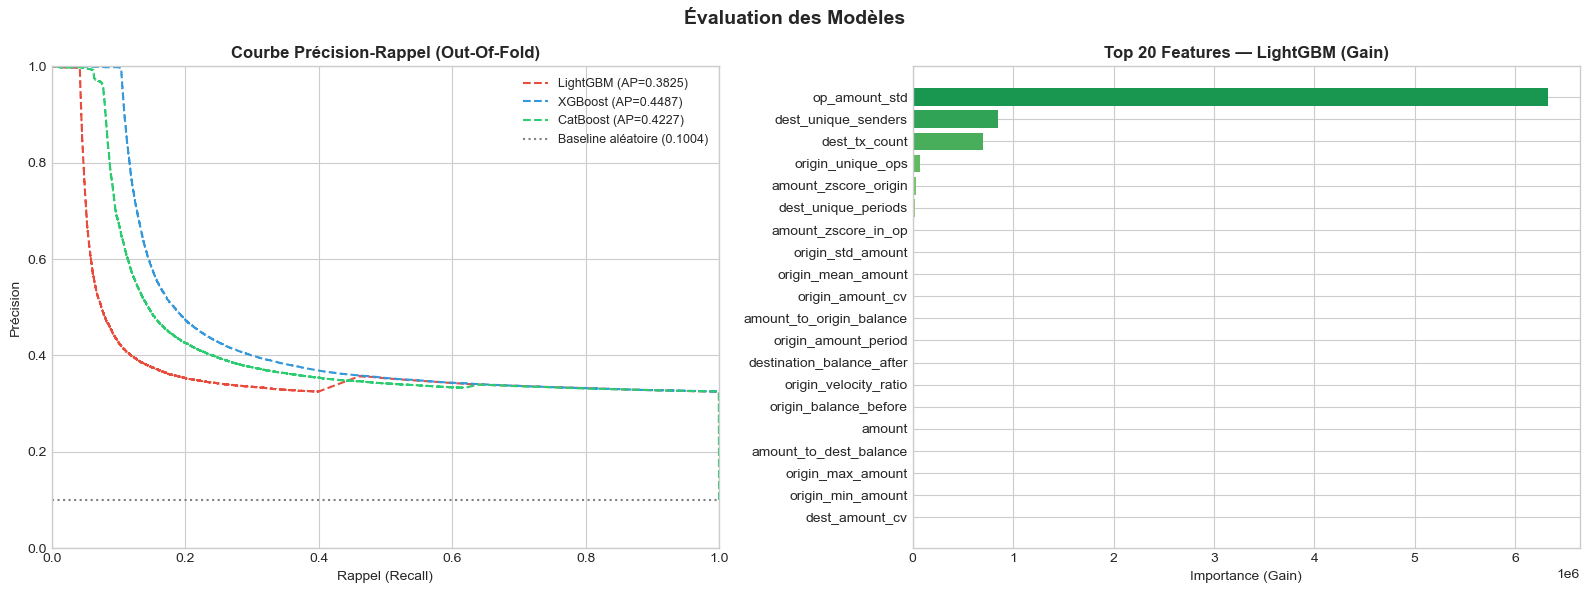

✅ Graphiques d'évaluation sauvegardés → model_evaluation.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Évaluation des Modèles', fontsize=14, fontweight='bold')

# Courbe Précision-Rappel pour chaque modèle (OOF)
ax = axes[0]
model_preds = [
    ('LightGBM', oof_lgb, '#e74c3c', '--'),
    ('XGBoost',  oof_xgb, '#3498db', '--'),
    ('CatBoost', oof_cat, '#2ecc71', '--'),
]
for name, oof, color, ls in model_preds:
    prec, rec, _ = precision_recall_curve(y_train, oof)
    ap = average_precision_score(y_train, oof)
    ax.plot(rec, prec, color=color, linestyle=ls, lw=1.5, label=f'{name} (AP={ap:.4f})')

ax.axhline(y_train.mean(), color='gray', linestyle=':', lw=1.5,
           label=f'Baseline aléatoire ({y_train.mean():.4f})')
ax.set_xlabel('Rappel (Recall)'); ax.set_ylabel('Précision')
ax.set_title('Courbe Précision-Rappel (Out-Of-Fold)', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1])

# Importance des features (LightGBM)
ax = axes[1]
imp_df = pd.DataFrame({
    'feature'    : FEATURES,
    'importance' : model_lgb.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True).tail(20)
colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(imp_df)))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors_imp)
ax.set_title('Top 20 Features — LightGBM (Gain)', fontweight='bold')
ax.set_xlabel('Importance (Gain)')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphiques d\'évaluation sauvegardés → model_evaluation.png')

---
## Étape 9 — Ensemble des Modèles

L'**ensemble** (combinaison de plusieurs modèles) améliore la performance en réduisant la variance.

On cherche les **poids optimaux** pour chaque modèle par recherche en grille sur les prédictions OOF.

In [25]:
print('Recherche des poids optimaux pour l\'ensemble...')

best_score = 0
best_w     = (1/3, 1/3, 1/3)

for w1 in np.arange(0.1, 0.81, 0.1):
    for w2 in np.arange(0.1, 0.81, 0.1):
        w3 = 1.0 - w1 - w2
        if w3 <= 0:
            continue
        blend = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cat
        sc    = average_precision_score(y_train, blend)
        if sc > best_score:
            best_score = sc
            best_w     = (round(w1,1), round(w2,1), round(w3,2))

w1, w2, w3 = best_w
print(f'\n  Poids optimaux :')
print(f'    LightGBM : {w1:.2f}')
print(f'    XGBoost  : {w2:.2f}')
print(f'    CatBoost : {w3:.2f}')
print(f'\n  Score OOF Ensemble (PR-AUC) : {best_score:.5f}')

# Prédictions finales
oof_final  = w1 * oof_lgb  + w2 * oof_xgb  + w3 * oof_cat
pred_final = w1 * pred_lgb + w2 * pred_xgb + w3 * pred_cat

print(f'\n  Comparaison des scores OOF :')
print(f'    LightGBM seul : {average_precision_score(y_train, oof_lgb):.5f}')
print(f'    XGBoost seul  : {average_precision_score(y_train, oof_xgb):.5f}')
print(f'    CatBoost seul : {average_precision_score(y_train, oof_cat):.5f}')
print(f'    Ensemble      : {best_score:.5f} ✅')

Recherche des poids optimaux pour l'ensemble...

  Poids optimaux :
    LightGBM : 0.10
    XGBoost  : 0.60
    CatBoost : 0.30

  Score OOF Ensemble (PR-AUC) : 0.44835

  Comparaison des scores OOF :
    LightGBM seul : 0.38251
    XGBoost seul  : 0.44872
    CatBoost seul : 0.42268
    Ensemble      : 0.44835 ✅


---
## Étape 10 — Calibration des Probabilités

La calibration garantit que les probabilités prédites sont **bien calibrées** :
- Si le modèle prédit 0.8, cela doit vraiment signifier 80% de chance de fraude
- On utilise le **Platt Scaling** (régression logistique sur les scores OOF)

Une bonne calibration est importante pour les systèmes de décision en production.

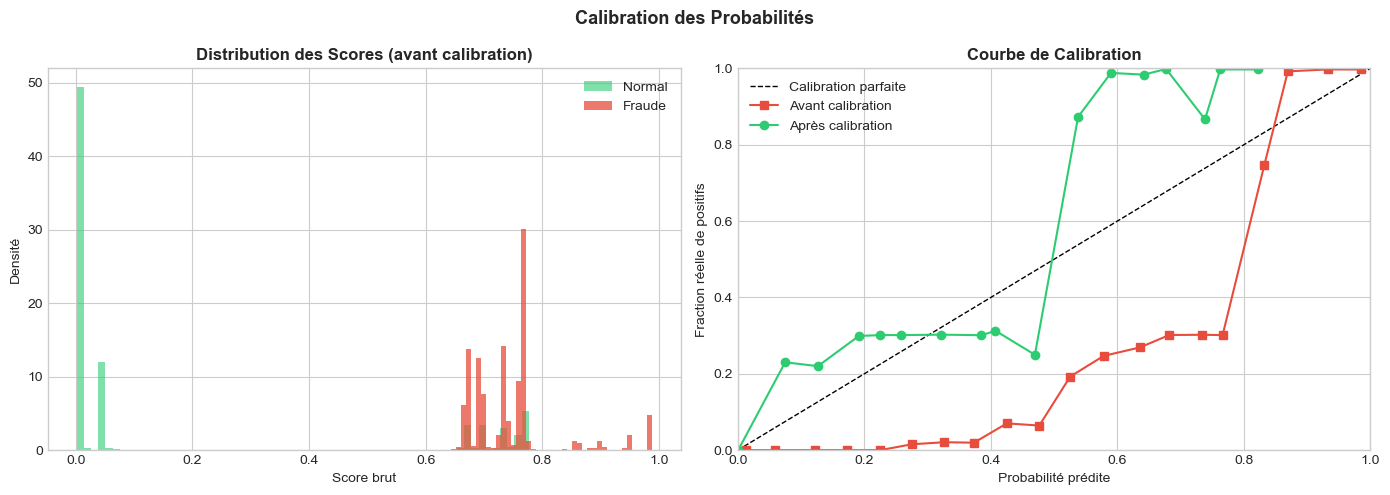


Statistiques des probabilités finales :
  Min    : 0.000656
  Max    : 0.748512
  Moyen  : 0.106998
  Médiane: 0.000663


In [26]:
# Calibration par Platt Scaling
calibrator = LogisticRegression(C=1.0, solver='lbfgs')
calibrator.fit(oof_final.reshape(-1, 1), y_train)
pred_calibrated = calibrator.predict_proba(pred_final.reshape(-1, 1))[:, 1]

# Visualisation de la calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calibration des Probabilités', fontsize=13, fontweight='bold')

# Avant calibration
ax = axes[0]
ax.hist(oof_final[y_train==0], bins=80, alpha=0.6, color='#2ecc71', label='Normal', density=True)
ax.hist(oof_final[y_train==1], bins=80, alpha=0.75, color='#e74c3c', label='Fraude', density=True)
ax.set_xlabel('Score brut'); ax.set_ylabel('Densité')
ax.set_title('Distribution des Scores (avant calibration)', fontweight='bold')
ax.legend()

# Calibration curve : fraction de positifs vs score moyen par bucket
ax = axes[1]
from sklearn.calibration import calibration_curve
prob_true_before, prob_pred_before = calibration_curve(y_train, oof_final, n_bins=20)
prob_true_after,  prob_pred_after  = calibration_curve(
    y_train, calibrator.predict_proba(oof_final.reshape(-1,1))[:,1], n_bins=20
)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Calibration parfaite')
ax.plot(prob_pred_before, prob_true_before, 's-', color='#e74c3c', lw=1.5, label='Avant calibration')
ax.plot(prob_pred_after,  prob_true_after,  'o-', color='#2ecc71', lw=1.5, label='Après calibration')
ax.set_xlabel('Probabilité prédite'); ax.set_ylabel('Fraction réelle de positifs')
ax.set_title('Courbe de Calibration', fontweight='bold')
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStatistiques des probabilités finales :')
print(f'  Min    : {pred_calibrated.min():.6f}')
print(f'  Max    : {pred_calibrated.max():.6f}')
print(f'  Moyen  : {pred_calibrated.mean():.6f}')
print(f'  Médiane: {np.median(pred_calibrated):.6f}')

---
## Étape 11 — Génération du Fichier de Soumission

On génère le fichier `submission.csv` avec les colonnes `id` et `target`.

In [27]:
submission = pd.DataFrame({
    'id'    : df_test['id'].values,
    'target': pred_calibrated
})

# Vérifications de qualité
assert len(submission) == len(df_test),             'Nombre de lignes incorrect !'
assert submission['id'].nunique() == len(submission),'IDs dupliqués !'
assert submission['target'].between(0,1).all(),      'Probabilités hors [0,1] !'
assert submission.isnull().sum().sum() == 0,          'Valeurs manquantes !'

submission.to_csv('submission.csv', index=False)

print('✅ Fichier de soumission créé : submission.csv')
print(f'   Lignes   : {len(submission):,}')
print(f'   Colonnes : {list(submission.columns)}')
print()
print('Aperçu :')
display(submission.head(10))

✅ Fichier de soumission créé : submission.csv
   Lignes   : 430,100
   Colonnes : ['id', 'target']

Aperçu :


,id,target
0,dtf_0000001_08a8a524,0.0007
1,dtf_0000002_ae0d3769,0.2961
2,dtf_0000003_843bab7c,0.3028
3,dtf_0000004_91643844,0.0007
4,dtf_0000005_17bd9a08,0.3050
5,dtf_0000006_252a6318,0.0007
6,dtf_0000007_52b0ffae,0.0007
7,dtf_0000008_c37743d9,0.0007
8,dtf_0000009_bff3cf50,0.3061
9,dtf_0000010_7f815b93,0.3034


---
## Résumé Final

| Étape | Description | Statut |
|-------|-------------|--------|
| 1 | Importation des bibliothèques | ✅ |
| 2 | Chargement des données | ✅ |
| 3 | Exploration des données (EDA) | ✅ |
| 4 | Visualisations | ✅ |
| 5 | Feature Engineering | ✅ |
| 6 | Préparation pour la modélisation | ✅ |
| 7 | Modélisation (LightGBM + XGBoost + CatBoost) | ✅ |
| 8 | Évaluation (PR-AUC, courbes) | ✅ |
| 9 | Ensemble des modèles | ✅ |
| 10 | Calibration des probabilités | ✅ |
| 11 | Génération du fichier de soumission | ✅ |

### Fichiers générés
- `eda_visualizations.png` — Graphiques d'exploration
- `model_evaluation.png` — Courbes d'évaluation + Feature Importance
- `calibration.png` — Courbe de calibration
- `submission.csv` — **Fichier à soumettre sur la plateforme**

### Points clés de l'approche
- **Métrique PR-AUC** : adaptée aux données fortement déséquilibrées
- **Feature Engineering** : anomalies de balance, vélocité par compte, z-scores
- **Ensemble** : LightGBM + XGBoost + CatBoost avec poids optimisés
- **Calibration** : probabilités bien calibrées pour la soumission